In [5]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.csv to online_retail.csv


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Database 'online_retail.db' created successfully with cleaned data
          Country       Revenue
0  United Kingdom  7.308392e+06
1     Netherlands  2.854463e+05
2            EIRE  2

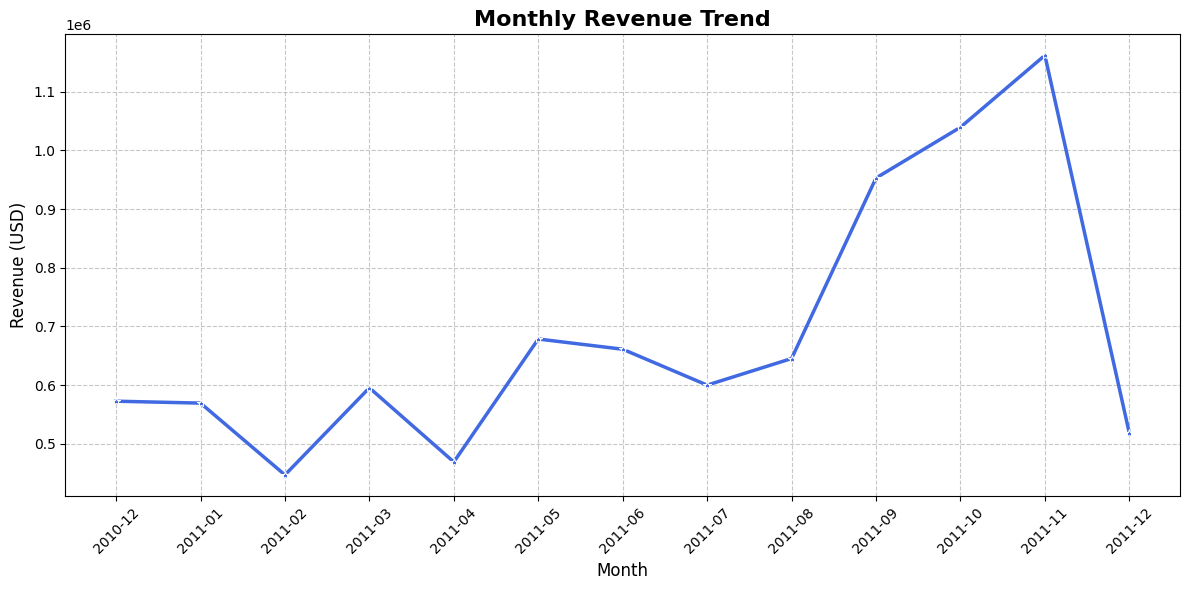

/tmp/ipykernel_22926/1261727723.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




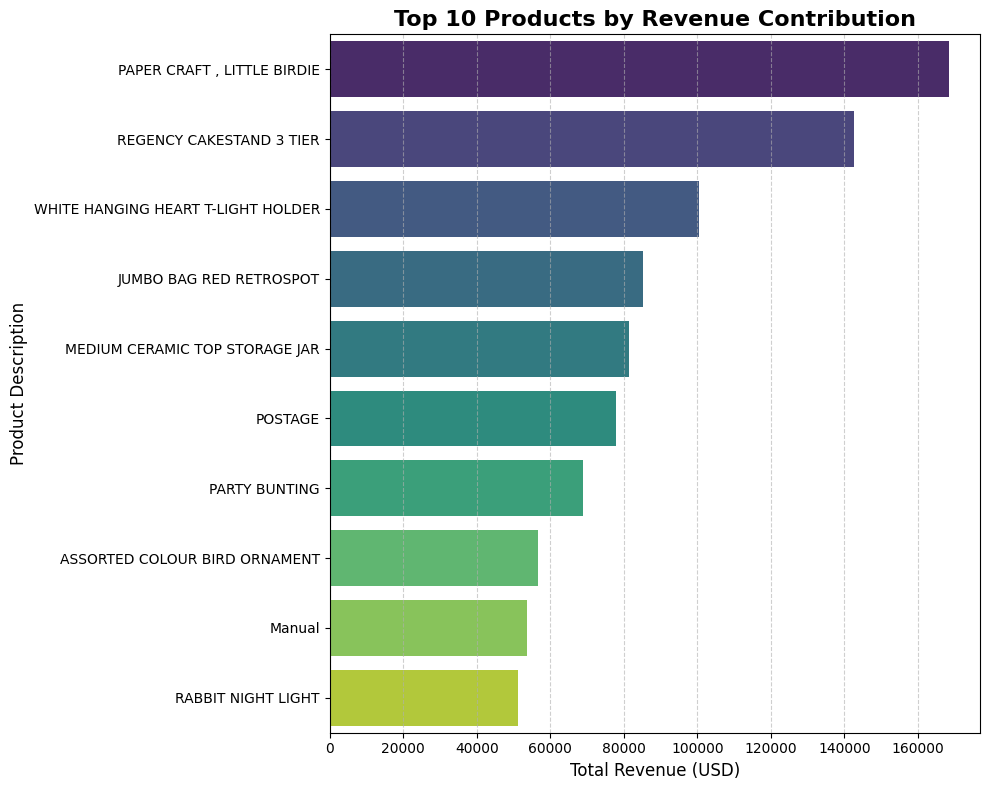

--- EXECUTION SUMMARY ---
Total Unique Customers: 4339
Total Successful Orders: 18536
Grand Total Revenue: $8,911,407.90
Average Order Value: $22.39


'\nconn.close()\nprint("\nDatabase connection closed safely.")\n'

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import datetime as dt
import plotly.express as px

df = pd.read_csv('online_retail.csv')

print(df.head())

df.describe()

df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0 ]
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

conn = sqlite3.connect('RetailData.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

print("Database 'online_retail.db' created successfully with cleaned data")

query = """
SELECT Country, SUM(TotalRevenue) as Revenue
FROM sales
GROUP BY Country
ORDER BY Revenue DESC
LIMIT 5
"""

top_countries = pd.read_sql_query(query, conn)
print(top_countries)

query_trends = """
SELECT strftime('%Y-%m', InvoiceDate) as Month,
SUM(TotalRevenue) as Revenue
FROM sales
GROUP BY Month
ORDER BY Month ASC;
"""

monthly_sales = pd.read_sql_query(query_trends, conn)

plt.figure(figsize=(12, 6))
sns.lineplot(data = monthly_sales, x = 'Month', y='Revenue', marker = '*', color = 'royalblue', linewidth=2.5)
plt.xticks(rotation = 45)
plt.title('Monthly Revenue Trend' , fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()

fig = px.line(monthly_sales, x='Month', y='Revenue', title='Interactive Revenue Overview',
labels = {'Revenue': 'TotalRevenue ($)'})
fig.show()

query_top_products = """
SELECT Description,
SUM(TotalRevenue) as ProductRevenue
FROM sales
GROUP BY Description
ORDER BY ProductRevenue DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query_top_products, conn)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_products, x='ProductRevenue', y='Description', palette='viridis')
plt.title('Top 10 Products by Revenue Contribution', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('top_products.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

summary_query = """
SELECT COUNT(DISTINCT CustomerID) as Total_Customers,
COUNT(DISTINCT InvoiceNo) as Total_Orders,
SUM(TotalRevenue) as Grand_Total_Revenue,
AVG(TotalRevenue) as Average_Transaction_Value
FROM sales;
"""

summary_stats = pd.read_sql_query(summary_query, conn)

print("--- EXECUTION SUMMARY ---")
print(f"Total Unique Customers: {int(summary_stats['Total_Customers'][0])}")
print(f"Total Successful Orders: {int(summary_stats['Total_Orders'][0])}")
print(f"Grand Total Revenue: ${summary_stats['Grand_Total_Revenue'][0]:,.2f}")
print(f"Average Order Value: ${summary_stats['Average_Transaction_Value'][0]:,.2f}")

'''
conn.close()
print("\nDatabase connection closed safely.")
'''

In [7]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

query_trends = "SELECT strftime('%Y-%m', InvoiceDate) as Month, SUM(TotalRevenue) as Revenue FROM sales GROUP BY Month ORDER BY Month ASC;"
monthly_data = pd.read_sql_query(query_trends, conn)


query_products = "SELECT Description, SUM(TotalRevenue) as ProductRevenue FROM sales GROUP BY Description ORDER BY ProductRevenue DESC LIMIT 10;"
top_products = pd.read_sql_query(query_products, conn)


fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Monthly Sales Performance", "Top 10 Products by Revenue Contribution"),
    vertical_spacing=0.15
)


fig.add_trace(
    go.Scatter(x=monthly_data['Month'], y=monthly_data['Revenue'], name="Revenue", line=dict(color='royalblue', width=4)),
    row=1, col=1
)


fig.add_trace(
    go.Bar(x=top_products['ProductRevenue'], y=top_products['Description'], orientation='h', name="Products", marker=dict(color='indianred')),
    row=2, col=1
)


fig.update_layout(
    height=900,
    title_text="Retail Sales Performance Dashboard",
    showlegend=False,
    template="plotly_white"
)

fig.show()